# ESBs Across the US

Dans ce notebook nous allons nous focaliser l'**adoption des bus dans les Etats du pays**.

Ainsi nous allons essayer de déterminer le profil des Etats : regrouper des Etats ayant des profils similaires.


### Dépendances

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA

from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## PREPROCESSING

In [2]:
RAW_FILE = "../data/ESB_v8.xlsx" # data file renamed
SHEET_STATE    = "3. State-level data"
SHEET_DISTRICT    = "1. District-level data"

MISSING_LOGICAL = {"Not applicable"}                         
MISSING_DATA    = {"Missing value", "Blank cell", "TBD",
                   "N/A", "NA", "", " "}                 

### Chargement des données

In [3]:
sheet1 = (pd.read_excel(RAW_FILE, sheet_name=SHEET_DISTRICT)
        .replace(list(MISSING_LOGICAL), "logical_na")
        .replace(list(MISSING_DATA), np.nan))

sheet3 = (pd.read_excel(RAW_FILE, sheet_name=SHEET_STATE)
        .replace(list(MISSING_LOGICAL), "logical_na")
        .replace(list(MISSING_DATA), np.nan))

In [4]:
#print(sheet1.columns.tolist())

In [5]:
#print(sheet3.columns.tolist())

## Préparer les données des Etats

In [6]:
df_state = sheet3[[
    "1a. State",
    "3a. Number of committed ESBs",
    "8a. Approximate total number of students riding ESBs",
    "2a. Total number of school buses (WRI 2024)",  # choisir une source stable
    "8b. Number of persons, mode to school: school bus",
    "8c. Percent of persons, mode to school: school bus"
]].copy()


df_state.columns = [
    "State", 
    "Committed_ESBs", 
    "Students_riding_ESBs", 
    "Total_school_buses_WRI",
    "Persons_mode_school_bus",
    "Percent_mode_school_bus"
]


### Limitations et traitement des données manquantes

L’analyse repose sur un jeu de données agrégé à partir de multiples sources (articles de presse, bases gouvernementales, bases internes WRI, etc.), ce qui introduit des incertitudes et des lacunes. En particulier :

- Données incomplètes à l’échelle des districts pour certains indicateurs clés (taille des flottes, statut socio-économique, opérateur privé).

- Imprécision temporelle dans le suivi des étapes d’adoption des bus électriques, souvent non datées précisément.

- Risque de double comptage : certains districts ont un modèle mixte (bus publiques et opérateur privé), ce qui peut entraîner une duplication des informations.

- Inégalités de couverture géographique : certaines zones sont mieux renseignées que d’autres.

Ces facteurs impliquent que les résultats doivent être interprétés avec prudence. Les moyennes, typologies ou clusters générés reflètent des tendances générales et non des mesures précises à l’unité près.

### Valeurs NaN

In [7]:
df_state.isna().sum()

State                      0
Committed_ESBs             0
Students_riding_ESBs       0
Total_school_buses_WRI     8
Persons_mode_school_bus    4
Percent_mode_school_bus    4
dtype: int64

Ici, on remarque qu'il manque des données sur le nombre de bus dans 8 Etats. En aggrégant les données de la première Feuille, on peut réduire cela à 1 (même si certains auront pour valeur 0).

In [8]:
# Total buses par état depuis sheet1 (niveau district)
total_buses_state = sheet1.groupby("1a. State")["2a. Total number of buses"].sum().reset_index()
total_buses_state.columns = ["State", "Total_buses_sheet1"]

# Merge avec df_state déjà créé
df_state = df_state.merge(total_buses_state, on="State", how="left")

# Vérifier les NaN
print(df_state[["Total_school_buses_WRI", "Total_buses_sheet1"]].isna().sum())

Total_school_buses_WRI    8
Total_buses_sheet1        1
dtype: int64


In [9]:
df_state_clean = df_state.drop(columns=["Total_school_buses_WRI"], inplace=True)

In [10]:
df_state.isna().sum()

State                      0
Committed_ESBs             0
Students_riding_ESBs       0
Persons_mode_school_bus    4
Percent_mode_school_bus    4
Total_buses_sheet1         1
dtype: int64

In [11]:
df_state.rename(columns={"Total_buses_sheet1": "Total_school_buses"}, inplace=True)

Nous avons choisi de retirer les lignes où des valeurs essentielles sont manquantes afin de garantir la qualité et la fiabilité de notre analyse. En effet, ces variables clés — telles que le nombre total de bus, le nombre d’élèves, ou le nombre de bus électriques engagés — sont nécessaire pour évaluer la progression du déploiement des bus électriques dans chaque État.

Imputer ces valeurs manquantes par zéro, la médiane, etc. pourrait introduire des biais importants et fausser les interprétations, car l’absence de données ne signifie pas une valeur nulle ou moyenne, mais simplement une indisponibilité d’information. Par conséquent, pour préserver la rigueur et l’intégrité des résultats, il est plus prudent d’exclure ces observations incomplètes.

### Ajout de nouvelles colonnes

In [12]:
# Total d'élèves par Etat depuis Sheet 1 (niveau district)
total_students_state = sheet1.groupby("1a. State")["4b. Number of students in district"].sum().reset_index()
total_students_state.columns = ["State", "Total_students"]

# Fusionner les deux dataframes sur state
df_state = df_state.merge(total_students_state, on="State", how="left")

# Calculs avec gestion de la division par 0/NaN

# Calculer le ratio ESBs par 1000 élèves
df_state["ESBs_per_1000_students_total"] = np.where(
    (df_state["Total_students"] > 0) & (~df_state["Total_students"].isna()),
    df_state["Committed_ESBs"] / df_state["Total_students"] * 1000,
    np.nan
)

# Ratio ESBs / Total buses (en %)
df_state["Percent_ESBs_vs_total_buses"] = np.where(
    (df_state["Total_school_buses"] > 0) & (~df_state["Total_school_buses"].isna()),
    (df_state["Committed_ESBs"] / df_state["Total_school_buses"]) * 100,
    np.nan
)

# Taux d’élèves utilisant les ESBs par rapport aux élèves totaux (en %)
df_state["Percent_students_using_ESBs"] = np.where(
    (df_state["Total_students"] > 0) & (~df_state["Total_students"].isna()),
    (df_state["Students_riding_ESBs"] / df_state["Total_students"]) * 100,
    np.nan
)

# Densité d’élèves par bus total
df_state["Students_per_bus"] = np.where(
    (df_state["Total_school_buses"] > 0) & (~df_state["Total_school_buses"].isna()),
    df_state["Total_students"] / df_state["Total_school_buses"],
    np.nan
)

# Densité d’élèves par ESB
df_state["Students_per_ESB"] = df_state.apply(
    lambda row: row["Students_riding_ESBs"] / row["Committed_ESBs"] if row["Committed_ESBs"] and row["Committed_ESBs"] != 0 else None,
    axis=1
)

df_state.head(2)

,State,Committed_ESBs,Students_riding_ESBs,Persons_mode_school_bus,Percent_mode_school_bus,Total_school_buses,Total_students,ESBs_per_1000_students_total,Percent_ESBs_vs_total_buses,Percent_students_using_ESBs,Students_per_bus,Students_per_ESB
0,ALABAMA,70,1283.713171,249000.0,0.363,10482.0,750923.0,0.093219,0.667811,0.170951,71.639286,18.338760
1,ALASKA,2,164.744283,34000.0,0.303,954.0,130723.0,0.015300,0.209644,0.126025,137.026205,82.372141


In [13]:
# Supprimer les lignes où il y a au moins un NaN
df_state_clean = df_state.dropna()

df_state_clean.isna().sum()

State                           0
Committed_ESBs                  0
Students_riding_ESBs            0
Persons_mode_school_bus         0
Percent_mode_school_bus         0
Total_school_buses              0
Total_students                  0
ESBs_per_1000_students_total    0
Percent_ESBs_vs_total_buses     0
Percent_students_using_ESBs     0
Students_per_bus                0
Students_per_ESB                0
dtype: int64

In [14]:
df_num = df_state_clean.drop(columns=["State"])
df_num.head()

,Committed_ESBs,Students_riding_ESBs,Persons_mode_school_bus,Percent_mode_school_bus,Total_school_buses,Total_students,ESBs_per_1000_students_total,Percent_ESBs_vs_total_buses,Percent_students_using_ESBs,Students_per_bus,Students_per_ESB
0,70,1283.713171,249000.0,0.363,10482.0,750923.0,0.093219,0.667811,0.170951,71.639286,18.338760
1,2,164.744283,34000.0,0.303,954.0,130723.0,0.015300,0.209644,0.126025,137.026205,82.372141
3,186,1302.705135,314000.0,0.299,6641.0,1141400.0,0.162958,2.800783,0.114132,171.871706,7.003791
4,91,1078.000000,265000.0,0.523,7016.0,493031.0,0.184573,1.297035,0.218648,70.272377,11.846154
5,3110,67461.761668,546000.0,0.089,18083.0,5854167.0,0.531246,17.198474,1.152372,323.738705,21.691885


### Matrice de Corrélation

In [15]:
df_num.corr()

,Committed_ESBs,Students_riding_ESBs,Persons_mode_school_bus,Percent_mode_school_bus,Total_school_buses,Total_students,ESBs_per_1000_students_total,Percent_ESBs_vs_total_buses,Percent_students_using_ESBs,Students_per_bus,Students_per_ESB
Committed_ESBs,1.000000,0.916452,0.376169,-0.205231,0.389402,0.772986,0.346963,0.014294,0.283952,-0.010604,0.025720
Students_riding_ESBs,0.916452,1.000000,0.237442,-0.150472,0.265714,0.625175,0.382763,0.003169,0.585395,-0.027440,0.297618
Persons_mode_school_bus,0.376169,0.237442,1.000000,0.214586,0.836788,0.747028,-0.071840,-0.129736,0.038633,-0.139825,-0.114159
Percent_mode_school_bus,-0.205231,-0.150472,0.214586,1.000000,0.007377,-0.196316,0.059256,0.089310,0.148271,0.034979,0.032836
Total_school_buses,0.389402,0.265714,0.836788,0.007377,1.000000,0.815549,-0.139116,-0.180031,-0.007202,-0.226483,-0.096551
Total_students,0.772986,0.625175,0.747028,-0.196316,0.815549,1.000000,0.017782,-0.084839,0.065442,-0.092617,-0.086867
ESBs_per_1000_students_total,0.346963,0.382763,-0.071840,0.059256,-0.139116,0.017782,1.000000,0.402355,0.506276,0.326095,-0.067569
Percent_ESBs_vs_total_buses,0.014294,0.003169,-0.129736,0.089310,-0.180031,-0.084839,0.402355,1.000000,0.042488,0.979983,-0.112830
Percent_students_using_ESBs,0.283952,0.585395,0.038633,0.148271,-0.007202,0.065442,0.506276,0.042488,1.000000,-0.000796,0.608398
Students_per_bus,-0.010604,-0.027440,-0.139825,0.034979,-0.226483,-0.092617,0.326095,0.979983,-0.000796,1.000000,-0.125672


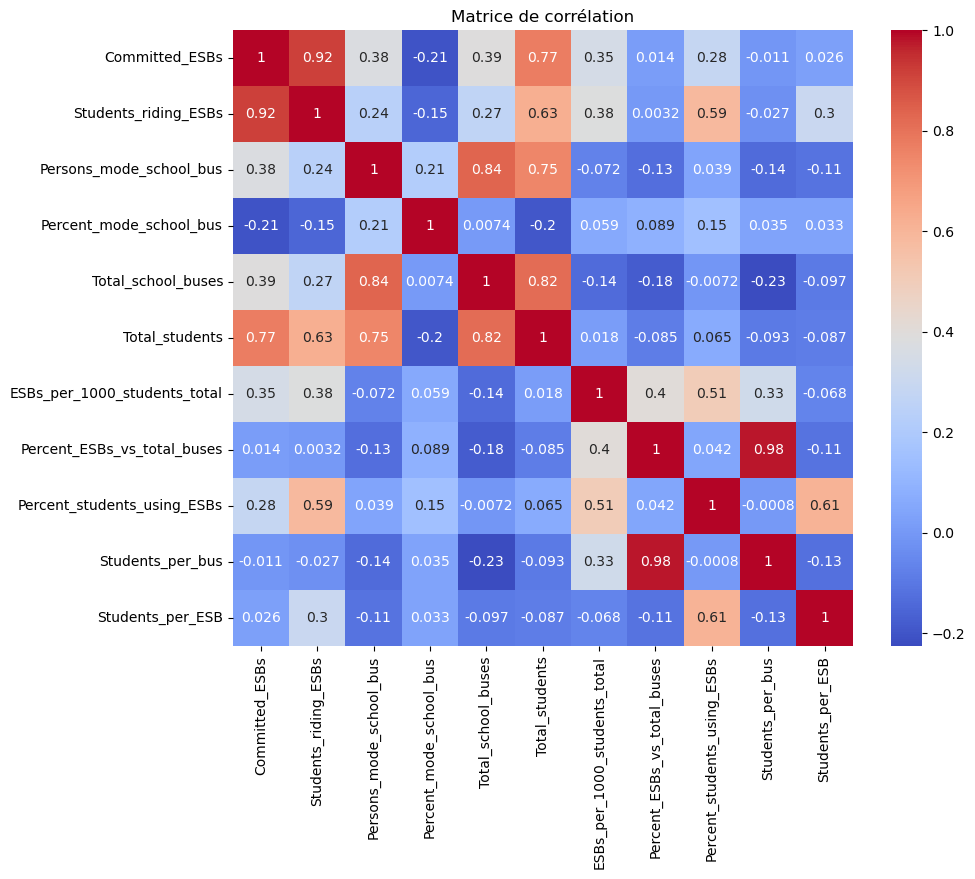

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

Committed_ESBs et Students_riding_ESBs : corrélation = 0.91

Total_students et Total_school_buses : corrélation = 0.81

Persons_mode_school_bus et Total_school_buses : corrélation = 0.84

Percent_ESBs_vs_total_buses et Students_per_bus : corrélation = 0.97

Percent_students_using_ESBs et Students_per_ESB : corrélation = 0.61

Committed_ESBs et Total_students : corrélation = 0.77

On ne va donc pas garder les variables fortement corrélées entre elles, à savoir *Committed_ESBs*, *Persons_mode_school_bus*, *Total_school_buses*, *Percent_ESBs_vs_total_buses*, 

In [17]:
features_to_keep = [
    'Students_riding_ESBs',
    'Percent_mode_school_bus',
    'Total_students',
    'ESBs_per_1000_students_total',
    'Percent_students_using_ESBs',
    'Students_per_bus',
    'Students_per_ESB'
]

X_selected = df_state_clean[features_to_keep]

## Standardisation

In [18]:
# Standardiser
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [19]:
df_scaled = pd.DataFrame(X_scaled, columns=features_to_keep)

# Remettre State pour les résultats (visualisations avec noms des Etats)
df_scaled["State"] = df_state_clean["State"].values
df_scaled.head()

,Students_riding_ESBs,Percent_mode_school_bus,Total_students,ESBs_per_1000_students_total,Percent_students_using_ESBs,Students_per_bus,Students_per_ESB,State
0,-0.336219,-0.220943,-0.243712,-0.919220,-0.456010,-0.332964,-0.022970,ALABAMA
1,-0.440589,-0.597829,-0.771090,-1.411725,-0.535354,-0.219701,3.901701,ALASKA
2,-0.334447,-0.622955,0.088325,-0.478418,-0.556358,-0.159341,-0.717702,ARIZONA
3,-0.355406,0.784087,-0.463006,-0.341797,-0.371774,-0.335332,-0.420908,ARKANSAS
4,5.836454,-1.942056,4.095757,1.849427,1.277274,0.103724,0.182546,CALIFORNIA


## Algorithmes (KMeans, GMM, Agglomerative, DBSCAN)

### Fonctions pour les scores et visualisations

**Dunn Index Function**

In [20]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    inter_cluster_distances = []
    intra_cluster_diameters = []

    for i in unique_clusters:
        cluster_i = X[labels == i]
        intra_dist = cdist(cluster_i, cluster_i)
        intra_cluster_diameters.append(np.max(intra_dist))

        for j in unique_clusters:
            if i < j:
                cluster_j = X[labels == j]
                inter_dist = cdist(cluster_i, cluster_j)
                inter_cluster_distances.append(np.min(inter_dist))

    return np.min(inter_cluster_distances) / np.max(intra_cluster_diameters)

In [21]:
def compute_scores(X, labels):
    """Fonction pour obtenir un ensemble de scores sur les clusters"""
    if len(np.unique(labels)) < 2:
        return (np.nan, np.nan, np.nan, np.nan)

    silhouette = silhouette_score(X, labels)
    davies = davies_bouldin_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    dunn = dunn_index(X, labels)

    return (silhouette, davies, calinski, dunn)

On fait tourner les algorithmes pour k clusters allant de 2 à 10.

In [22]:
k_values = range(2, 11)

scores_kmeans = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}
scores_gmm = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}
scores_agglo = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}

for k in k_values:
    # KMeans
    km_labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    s, d, c, di = compute_scores(X_scaled, km_labels)
    scores_kmeans["silhouette"].append(s)
    scores_kmeans["davies"].append(d)
    scores_kmeans["calinski"].append(c)
    scores_kmeans["dunn"].append(di)

    # GMM
    gmm_labels = GaussianMixture(n_components=k, random_state=42).fit(X_scaled).predict(X_scaled)
    s, d, c, di = compute_scores(X_scaled, gmm_labels)
    scores_gmm["silhouette"].append(s)
    scores_gmm["davies"].append(d)
    scores_gmm["calinski"].append(c)
    scores_gmm["dunn"].append(di)

    # Agglomerative
    agg_labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_scaled)
    s, d, c, di = compute_scores(X_scaled, agg_labels)
    scores_agglo["silhouette"].append(s)
    scores_agglo["davies"].append(d)
    scores_agglo["calinski"].append(c)
    scores_agglo["dunn"].append(di)

C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\maxka\anaconda3\envs\ml2-projet

In [23]:
def plot_clustering_scores(k_values, scores_dicts, algo_names):
    metrics = ["silhouette", "davies", "calinski", "dunn"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        for scores, name in zip(scores_dicts, algo_names):
            ax.plot(k_values, scores[metric], marker='o', label=name)
        ax.set_title(metric.capitalize())
        ax.set_xlabel("Nombre de clusters (k)")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

    plt.suptitle("Comparaison des algorithmes de clustering", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

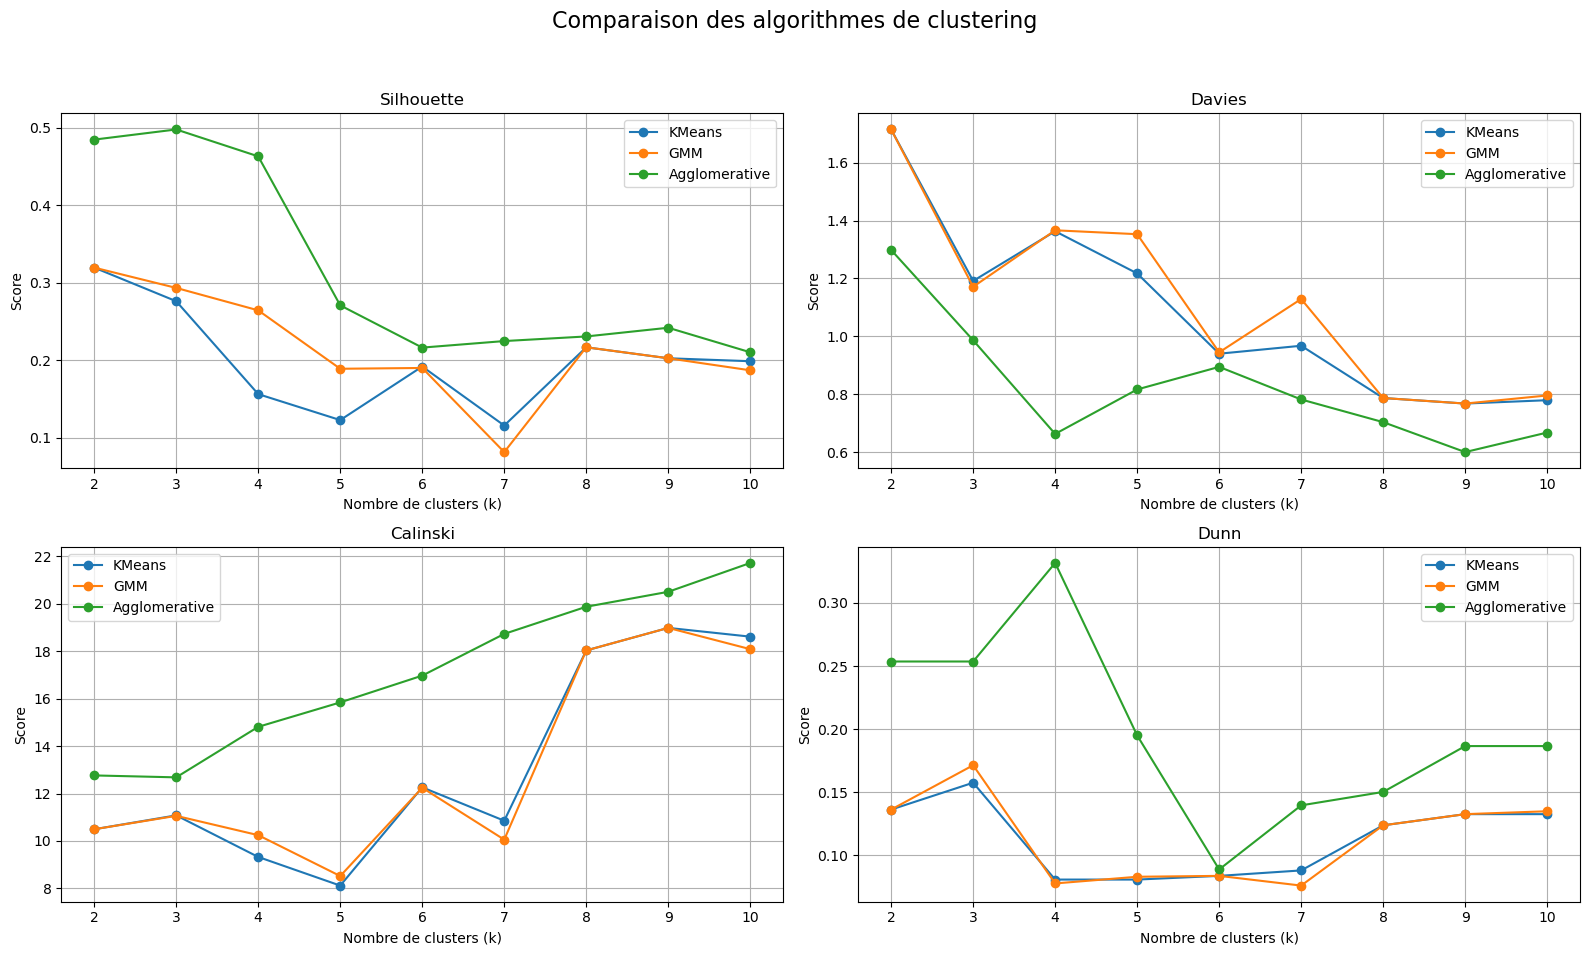

In [24]:
plot_clustering_scores(
    k_values,
    [scores_kmeans, scores_gmm, scores_agglo],
    ["KMeans", "GMM", "Agglomerative"]
)

Pour Kmeans et GMM, à partir des 4 scores, on peut envisager de dire qu'il est mieux de prendre 8 clusters (ou 8 distributions): k=8. 

Pour Agglomerative, on en prend 4 : k=4.

### DBScan

On définit qu'il faut au moins 3 points dans le voisinage d'un autre point pour qu'il soit considéré comme point coeur. Par la suite on prendra une liste d'*eps* pour faire tourner DBScan sur plusieurs distances donnant le voisinage.

In [25]:
def evaluate_dbscan(X, eps_values, min_samples=3):
    """Teste différents eps pour DBSCAN et renvoie les scores."""
    results = []

    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        silhouette, davies, calinski, dunn = compute_scores(X, labels)

        results.append({
            'eps': eps,
            'n_clusters': n_clusters,
            'silhouette': silhouette,
            'davies_bouldin': davies,
            'calinski_harabasz': calinski,
            'dunn': dunn
        })

    return pd.DataFrame(results)

In [26]:
def plot_dbscan_scores(results_df):
    plt.figure(figsize=(14, 8))
    metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'dunn']
    
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.plot(results_df['eps'], results_df[metric], marker='o')
        plt.title(f'{metric}')
        plt.xlabel('eps')
        plt.ylabel(metric)
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()


In [27]:
eps_values = np.arange(0.5, 6, 0.3)
df_dbscan_results = evaluate_dbscan(X_scaled, eps_values)
df_dbscan_results

,eps,n_clusters,silhouette,davies_bouldin,calinski_harabasz,dunn
0,0.5,0,NaN,NaN,NaN,NaN
1,0.8,2,-0.048655,2.315164,1.922988,0.079313
2,1.1,2,0.115632,2.863034,3.643161,0.119751
3,1.4,2,0.131821,2.917051,3.976203,0.134388
4,1.7,1,0.423309,2.583492,5.725190,0.165705
5,2.0,1,0.479927,1.952474,9.084086,0.231789
6,2.3,1,0.479927,1.952474,9.084086,0.231789
7,2.6,1,0.531428,2.262233,6.868557,0.249576
8,2.9,1,0.561995,1.906656,8.510559,0.281758
9,3.2,1,0.603770,1.465315,11.646988,0.369085


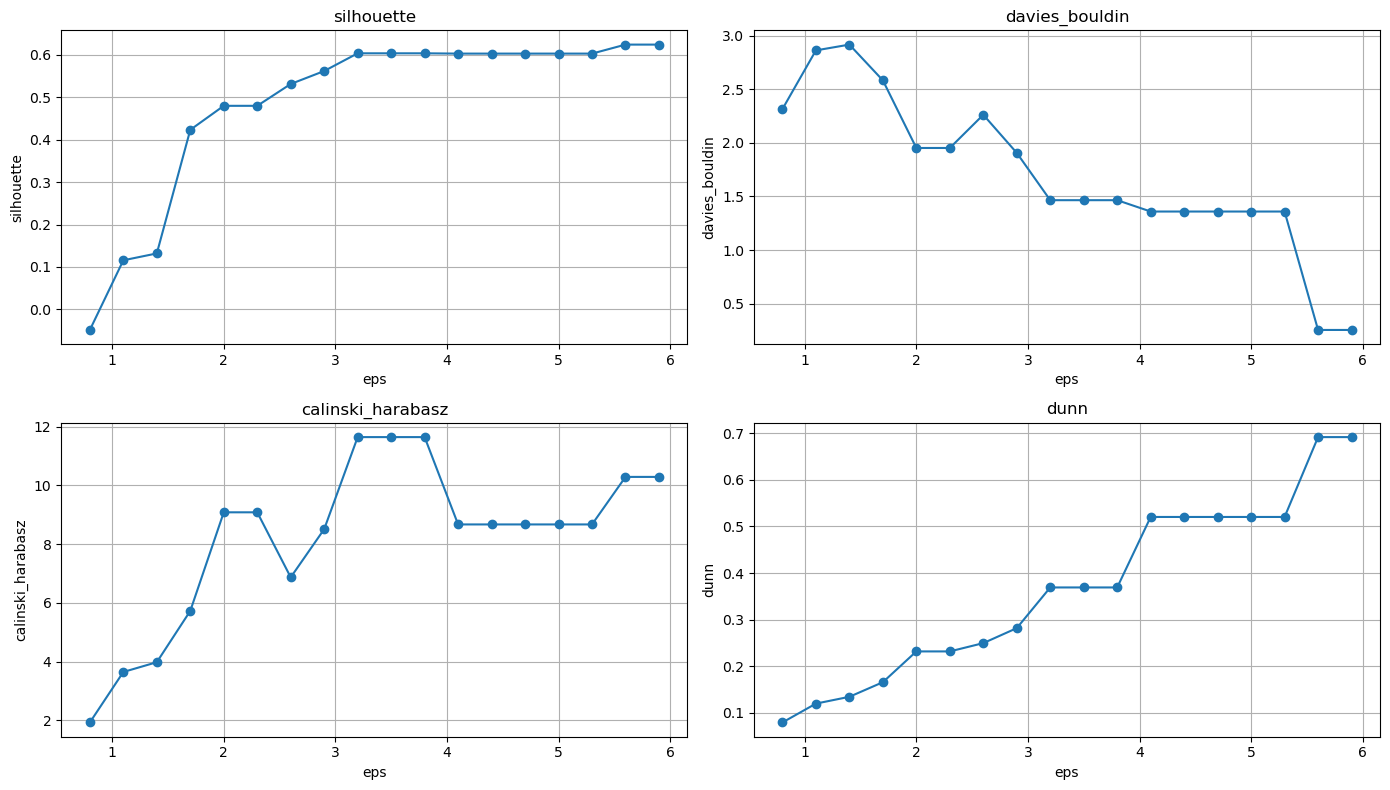

In [28]:
plot_dbscan_scores(df_dbscan_results)

Pour DBSCAN, en prenant en compte les 4 scores et min_samples=3, la distance qui semble la plus optimale est une distance eps appartenant à l'intervalle [5.6 ; 5.9]. On prendra donc eps = 5.6

## Visualisations

In [44]:
kmeans = KMeans(n_clusters=8, random_state=42)
gmm = GaussianMixture(n_components=8, random_state=42)
agglo = AgglomerativeClustering(n_clusters=4)
dbscan = DBSCAN(eps=5.6, min_samples=3)

In [45]:
labels_kmeans = kmeans.fit_predict(X_scaled)
labels_gmm = gmm.fit_predict(X_scaled)
labels_agglo = agglo.fit_predict(X_scaled)
labels_dbscan = dbscan.fit_predict(X_scaled)

C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [46]:
def plot_clusters_with_labels(X_2d, labels, title, states):
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(labels)
    palette = sns.color_palette("tab10", len(unique_labels) + 1)

    for label in unique_labels:
        # création d'un tableau de booléens
        mask = labels == label
        color = 'k' if label == -1 else palette[label % len(palette)]
        label_name = 'Outlier' if label == -1 else f'Cluster {label}'
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label_name, color=color, alpha=0.6, edgecolor='k')

        # Annoter les États
        for i in np.where(mask)[0]:
            plt.text(X_2d[i, 0]+0.1, X_2d[i, 1], states[i], fontsize=8, alpha=0.8)

    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### t-SNE

Tests de plusieurs paramètres d t-SNE

In [47]:
# perplexities = range(3,10)
#early_exaggerations = range(12,20,2)

#for perp in perplexities:
    #for exagger in early_exaggerations:
        #tsne = TSNE(n_components=2, perplexity=perp, early_exaggeration=exagger, random_state=42, n_iter=2000)
        #X_tsne = tsne.fit_transform(X_scaled)
        #plot_clusters_with_labels(X_tsne, labels_kmeans, f"t-SNE perp={perp}, early_exag={exagger}", states)

In [48]:
tsne = TSNE(n_components=2, perplexity=5, early_exaggeration=14, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

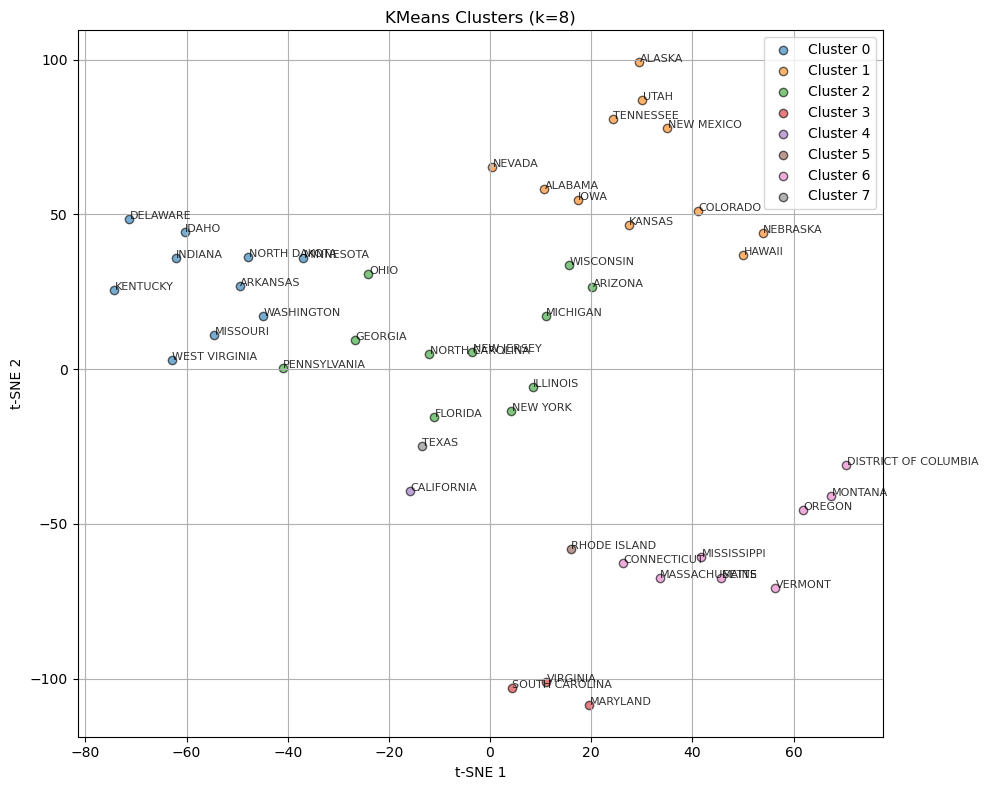

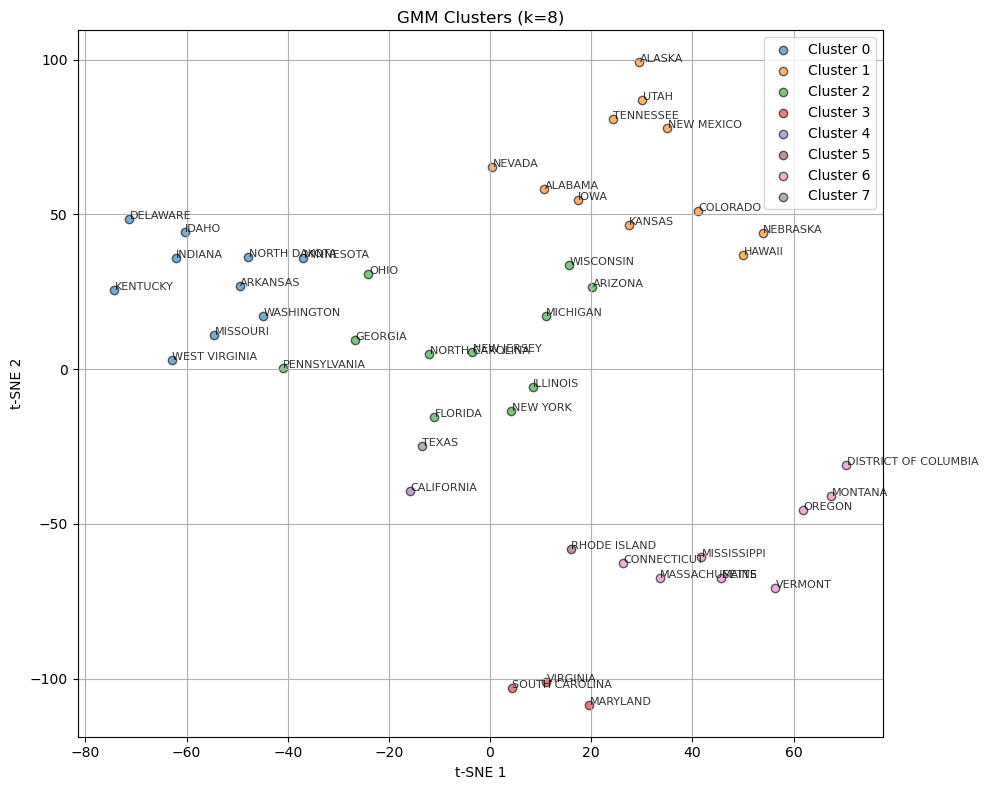

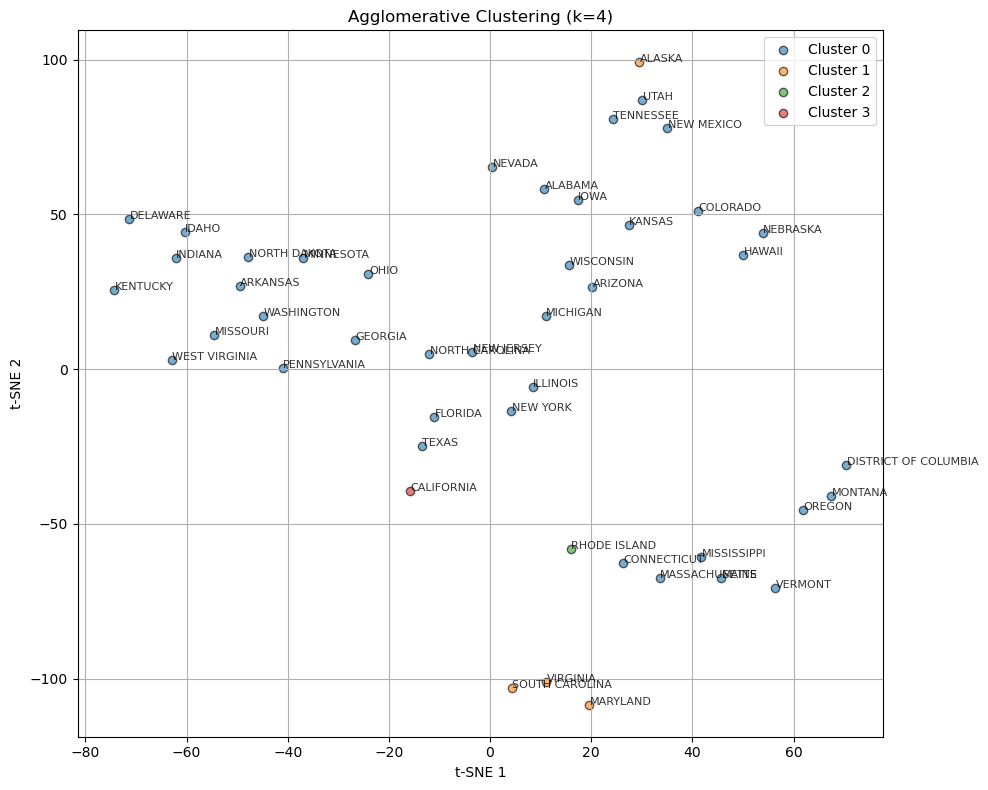

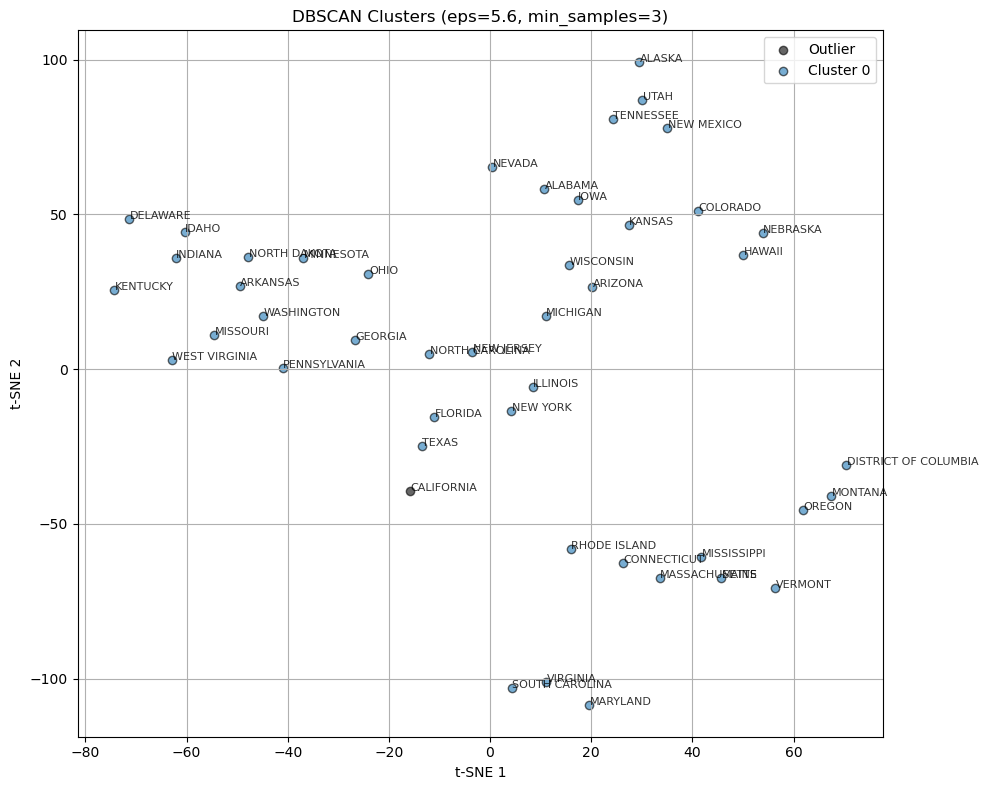

In [51]:
states = df_state_clean["State"].values  

plot_clusters_with_labels(X_tsne, labels_kmeans, "KMeans Clusters (k=8)", states)
plot_clusters_with_labels(X_tsne, labels_gmm, "GMM Clusters (k=8)", states)
plot_clusters_with_labels(X_tsne, labels_agglo, "Agglomerative Clustering (k=4)", states)
plot_clusters_with_labels(X_tsne, labels_dbscan, "DBSCAN Clusters (eps=5.6, min_samples=3)", states)

# Kernel PCA

Les variables n'étant pas linéairement séparables et les résultats étant médiocres sans réduction de la dimensionalité, on va essayer de représenter les données dans un nouvel espace en utilisant Kernel PCA.

In [35]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=42)
X_kpca = kpca.fit_transform(X_scaled)

On fait tourner les algos pour k clusters allant de 2 à 10

In [39]:
k_values = range(2, 11)

scores_kmeans_kpca = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}
scores_gmm_kpca = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}
scores_agglo_kpca = {"silhouette": [], "davies": [], "calinski": [], "dunn": []}

for k in k_values:
    # KMeans
    km_labels_kpca = KMeans(n_clusters=k, random_state=42).fit_predict(X_kpca)
    s, d, c, di = compute_scores(X_kpca, km_labels_kpca)
    scores_kmeans_kpca["silhouette"].append(s)
    scores_kmeans_kpca["davies"].append(d)
    scores_kmeans_kpca["calinski"].append(c)
    scores_kmeans_kpca["dunn"].append(di)

    # GMM
    gmm_labels_kpca = GaussianMixture(n_components=k, random_state=42).fit_predict(X_kpca)
    s, d, c, di = compute_scores(X_kpca, gmm_labels_kpca)
    scores_gmm_kpca["silhouette"].append(s)
    scores_gmm_kpca["davies"].append(d)
    scores_gmm_kpca["calinski"].append(c)
    scores_gmm_kpca["dunn"].append(di)

    # Agglomerative
    agg_labels_kpca = AgglomerativeClustering(n_clusters=k).fit_predict(X_kpca)
    s, d, c, di = compute_scores(X_kpca, agg_labels_kpca)
    scores_agglo_kpca["silhouette"].append(s)
    scores_agglo_kpca["davies"].append(d)
    scores_agglo_kpca["calinski"].append(c)
    scores_agglo_kpca["dunn"].append(di)

C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\clust

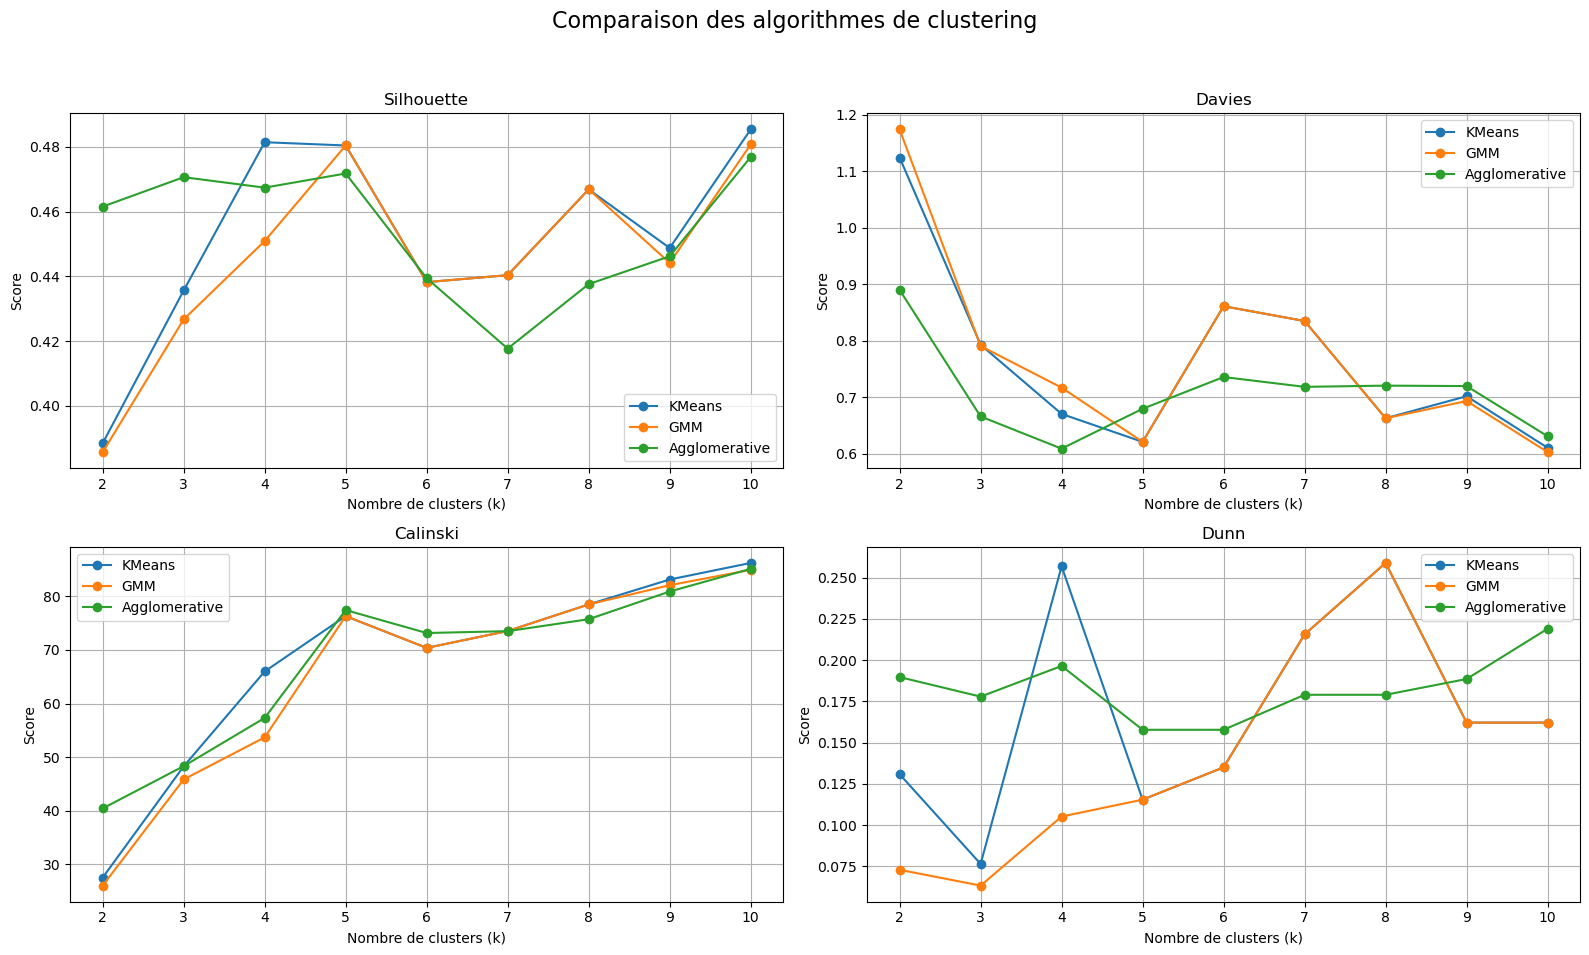

In [40]:
plot_clustering_scores(
    k_values,
    [scores_kmeans_kpca, scores_gmm_kpca, scores_agglo_kpca],
    ["KMeans", "GMM", "Agglomerative"]
)

Pour Kmeans, à partir des 4 scores, on peut envisager de dire qu'il est mieux de prendre 10 clusters : k=10. 

Pour GMM, on en prend 10 : k=10.

Pour Agglomerative, on en prend 4 : k=4.

### DBSCAN

In [75]:
eps_values = np.arange(0.01, 0.25, 0.01)
df_dbscan_kpca_results = evaluate_dbscan(X_kpca, eps_values)
df_dbscan_kpca_results

,eps,n_clusters,silhouette,davies_bouldin,calinski_harabasz,dunn
0,0.01,0,NaN,NaN,NaN,NaN
1,0.02,0,NaN,NaN,NaN,NaN
2,0.03,0,NaN,NaN,NaN,NaN
3,0.04,1,-0.073547,1.150223,2.258994,0.040258
4,0.05,3,-0.001492,0.949079,5.641290,0.050611
5,0.06,4,-0.012743,0.898586,7.907796,0.069262
6,0.07,4,0.079858,0.882440,9.862571,0.072751
7,0.08,4,0.112247,0.872228,11.093693,0.095109
8,0.09,5,0.109200,0.923469,10.682411,0.095109
9,0.10,6,0.254891,0.956309,16.184536,0.105206


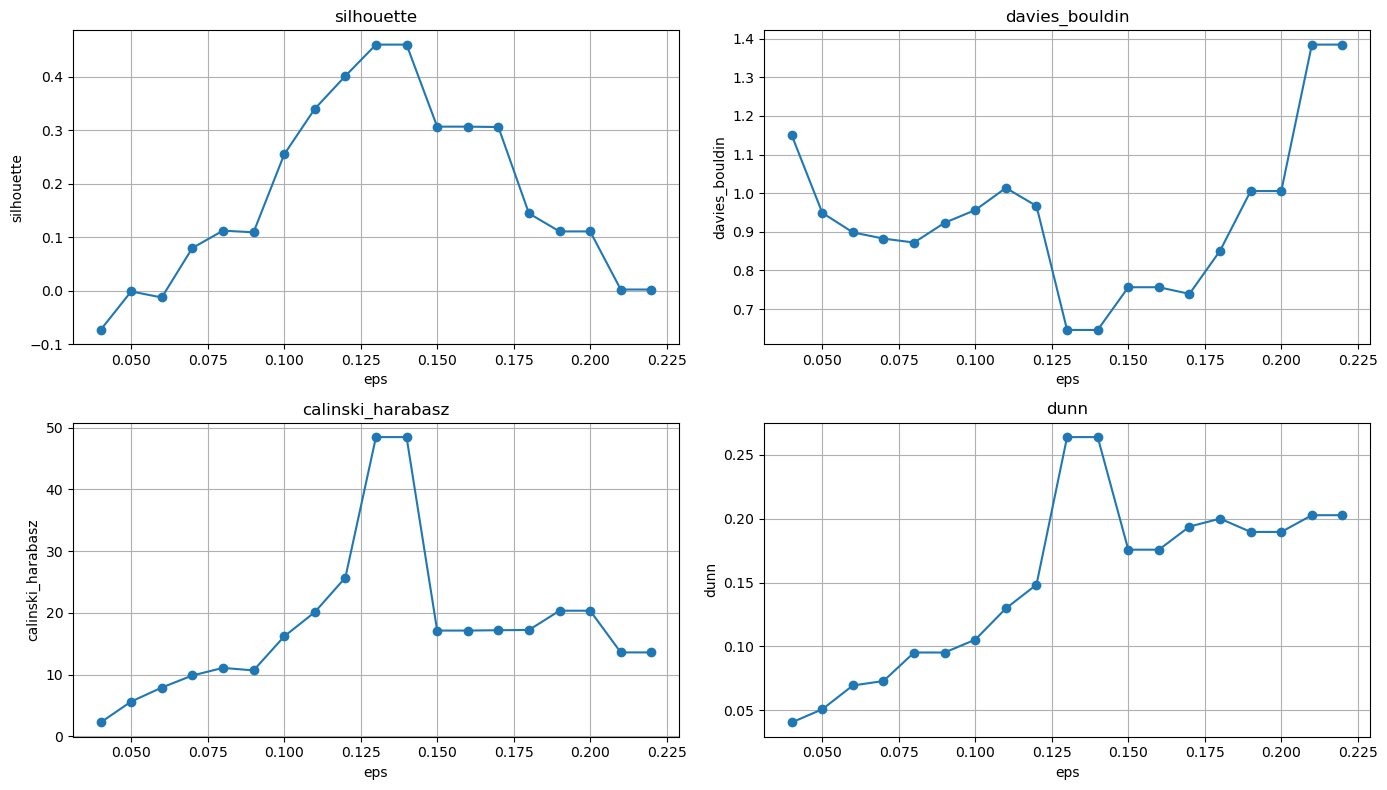

In [76]:
plot_dbscan_scores(df_dbscan_kpca_results)

Pour DBSCAN, en prenant en compte les 4 scores et min_samples=3, la distance qui semble la plus optimale est une distance eps appartenant à l'intervalle [0.13 ; 0.14]. On prendra donc eps = 0.13

### Visualisations avec t-SNE

In [77]:
tsne = TSNE(n_components=2, perplexity=5, early_exaggeration=14, random_state=42)
X_tsne_kpca = tsne.fit_transform(X_kpca)

In [78]:
kmeans_kpca = KMeans(n_clusters=10, random_state=42)
gmm_kpca = GaussianMixture(n_components=10, random_state=42)
agglo_kpca = AgglomerativeClustering(n_clusters=4)
dbscan_kpca = DBSCAN(eps=0.13, min_samples=3)

In [79]:
labels_kmeans_kpca = kmeans_kpca.fit_predict(X_kpca)
labels_gmm_kpca = gmm_kpca.fit_predict(X_kpca)
labels_agglo_kpca = agglo_kpca.fit_predict(X_kpca)
labels_dbscan_kpca = dbscan_kpca.fit_predict(X_kpca)

C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\maxka\anaconda3\envs\ml2-projet-bus\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


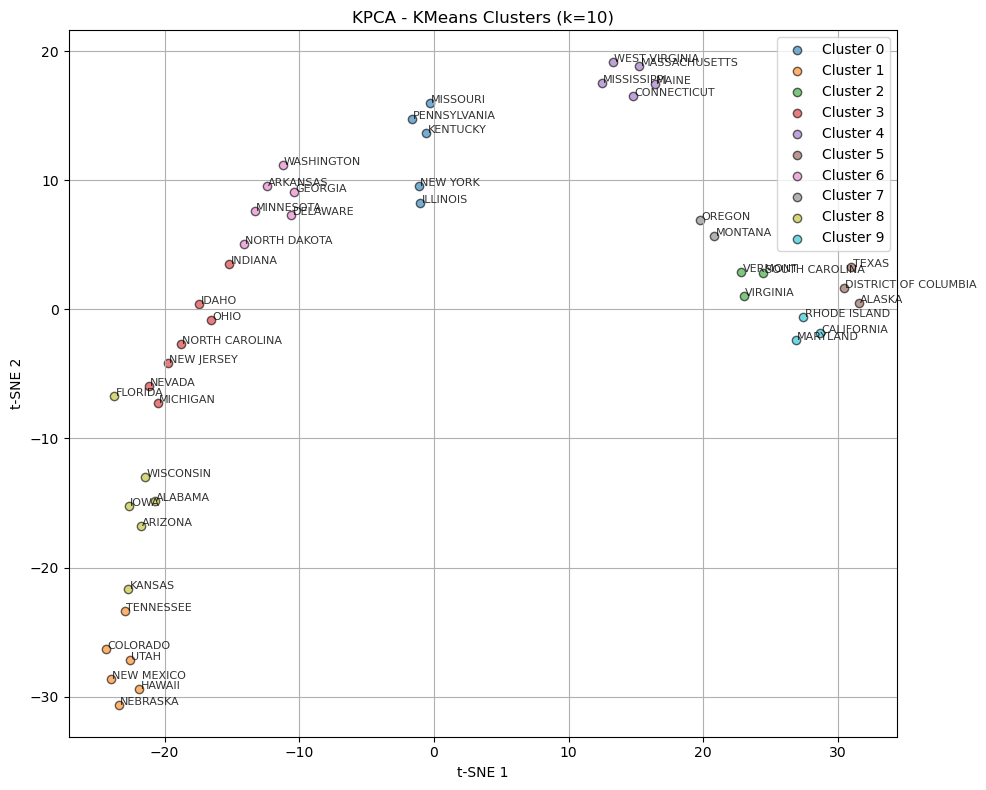

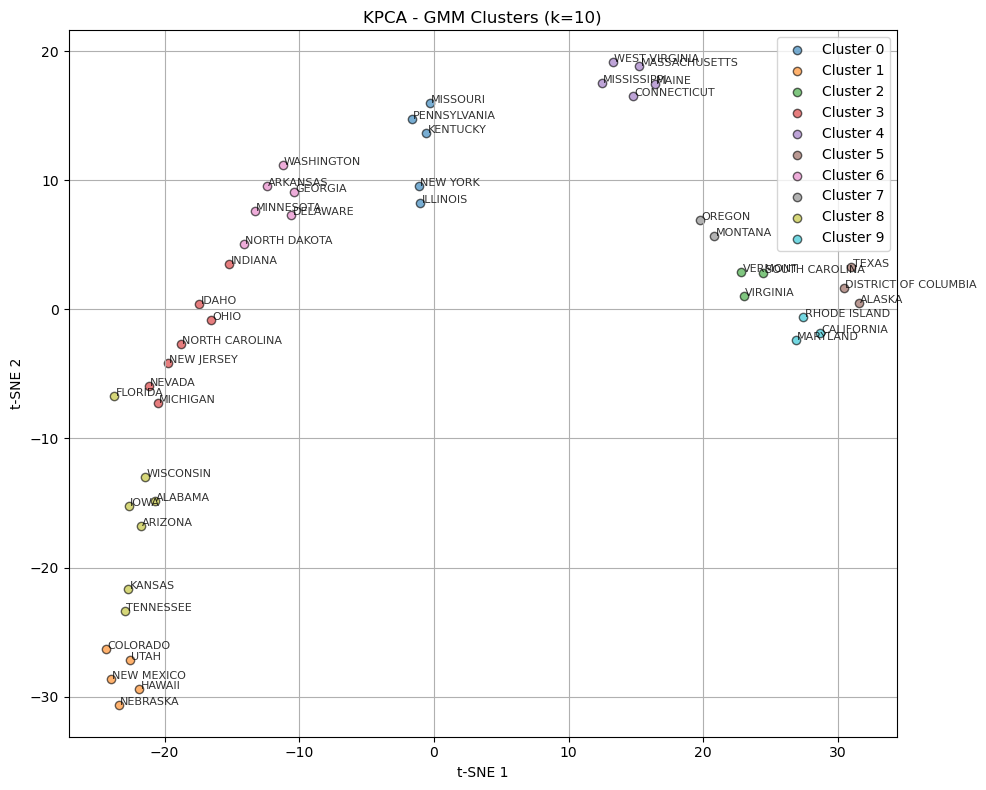

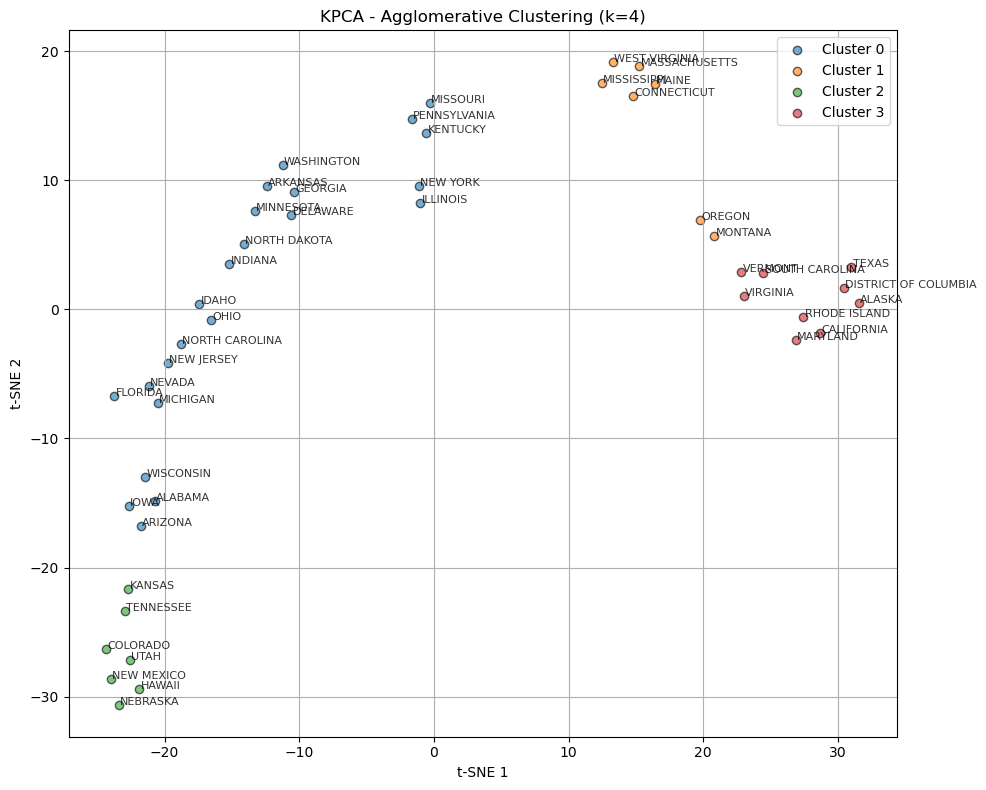

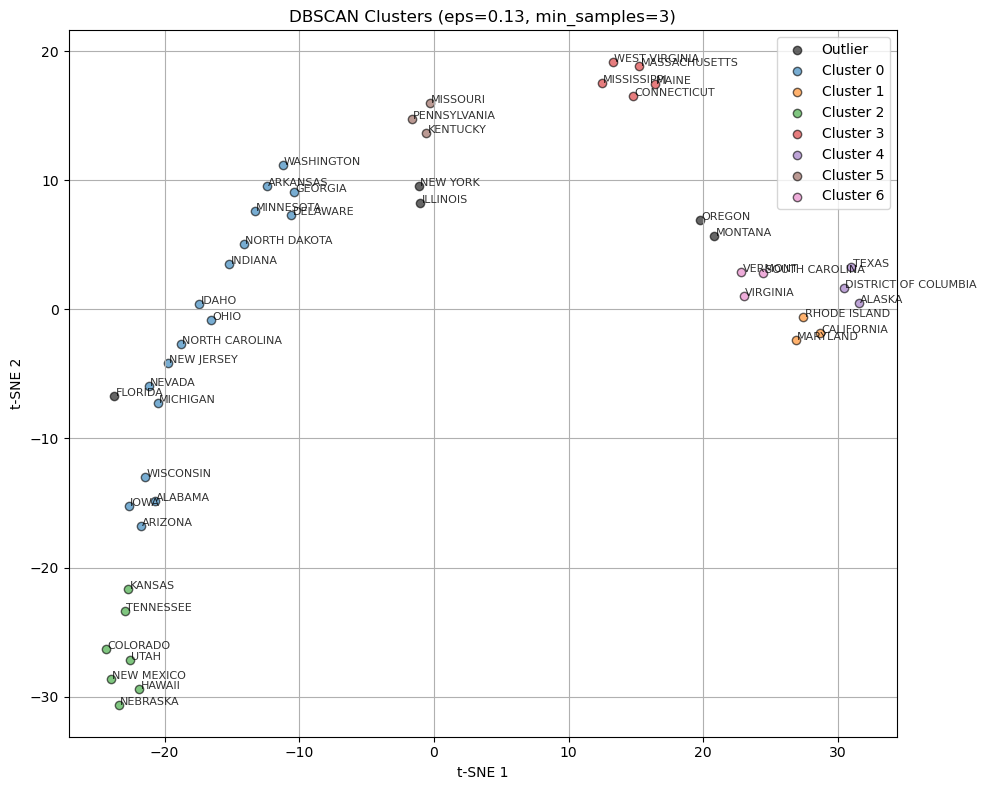

In [82]:
states = df_state_clean["State"].values  

plot_clusters_with_labels(X_tsne_kpca, labels_kmeans_kpca, "KPCA - KMeans Clusters (k=10)", states)
plot_clusters_with_labels(X_tsne_kpca, labels_gmm_kpca, "KPCA - GMM Clusters (k=10)", states)
plot_clusters_with_labels(X_tsne_kpca, labels_agglo_kpca, "KPCA - Agglomerative Clustering (k=4)", states)
plot_clusters_with_labels(X_tsne_kpca, labels_dbscan_kpca, "DBSCAN Clusters (eps=0.13, min_samples=3)", states)